<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/03_sustax_event_analysis_2015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración e imports**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/Doctorado-DCAG"
os.chdir(PROJECT_PATH)
sys.path.append(PROJECT_PATH)

print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Doctorado-DCAG


# **Imports**

In [3]:
from scripts.sustax.extremes import (
    build_event_scenarios_table,
    build_event_validation_summary
)

# **Configuración**

In [4]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"

SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")
MERGED_DIR = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED")

print("SUSTAX_DIR:", SUSTAX_DIR)

SUSTAX_DIR: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax


In [5]:
TARGET_DATE = "2015-10-23"

BYSCEN_TOTAL_FOLDER = os.path.join(MERGED_DIR, "BY_SCENARIO_TOTAL")
OBS_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "OBS_COMPOSITES_TOTAL")

# **Tabla de escenarios**

In [6]:
df_event_scenarios = build_event_scenarios_table(
    byscen_total_folder=BYSCEN_TOTAL_FOLDER,
    target_date=TARGET_DATE
)

display(df_event_scenarios.head())

,sustax_total,scenario,event_value_mm,monthly_max_2015_10_mm,october_percentile,october_rank,n_october_years
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,0.343163,13.985031,73.529412,75,102
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,0.892510,6.900040,65.686275,67,102
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,0.275105,4.003961,27.450980,28,102
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,0.712683,9.115235,63.725490,65,102
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,10.515098,22.831460,47.058824,48,102


# **Carga de OBS**

In [7]:
import glob

obs_simple_files = glob.glob(os.path.join(OBS_TOTAL_FOLDER, "OBS_SIMPLE__*.csv"))
obs_idw_files = glob.glob(os.path.join(OBS_TOTAL_FOLDER, "OBS_IDW__*.csv"))

obs_simple_dict = {}
obs_idw_dict = {}

for f in obs_simple_files:
    key = os.path.basename(f).replace("OBS_SIMPLE__", "").replace(".csv","")
    df = pd.read_csv(f)
    obs_simple_dict[key] = df

for f in obs_idw_files:
    key = os.path.basename(f).replace("OBS_IDW__", "").replace(".csv","")
    df = pd.read_csv(f)
    obs_idw_dict[key] = df

# **Validación evento**

In [8]:
df_validation = build_event_validation_summary(
    obs_simple_total_dict=obs_simple_dict,
    obs_idw_total_dict=obs_idw_dict,
    df_event_scenarios=df_event_scenarios,
    target_date=TARGET_DATE
)

display(df_validation.head())

,sustax_total,scenario,obs_simple_mm,obs_idw_mm,era5_mm,era5_obs_ratio,scenario_event_mm,scenario_monthly_max_mm,scenario_oct_percentile
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,240.042857,201.392467,NaN,NaN,0.343163,13.985031,73.529412
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,240.042857,201.392467,NaN,NaN,0.892510,6.900040,65.686275
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,240.042857,201.392467,NaN,NaN,0.275105,4.003961,27.450980
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,240.042857,201.392467,NaN,NaN,0.712683,9.115235,63.725490
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,240.042857,201.392467,NaN,NaN,10.515098,22.831460,47.058824


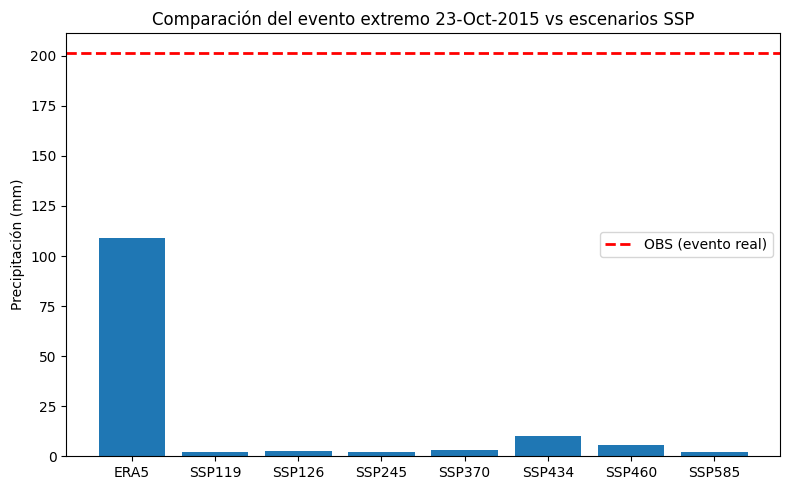

In [10]:
import matplotlib.pyplot as plt

# filtrar un punto (ejemplo)
point = "Sustax_MinatitlanTotal"
df_plot = df_event_scenarios[df_event_scenarios["sustax_total"] == point]

# valores
scenarios = df_plot["scenario"]
values = df_plot["event_value_mm"]

# OBS (usa IDW que es más robusto)
obs_value = 201.39  # ajusta si quieres dinámico

plt.figure(figsize=(8,5))

plt.bar(scenarios, values)

# línea OBS
plt.axhline(obs_value, color="red", linestyle="--", linewidth=2, label="OBS (evento real)")

plt.ylabel("Precipitación (mm)")
plt.title("Comparación del evento extremo 23-Oct-2015 vs escenarios SSP")
plt.legend()

plt.tight_layout()
plt.show()

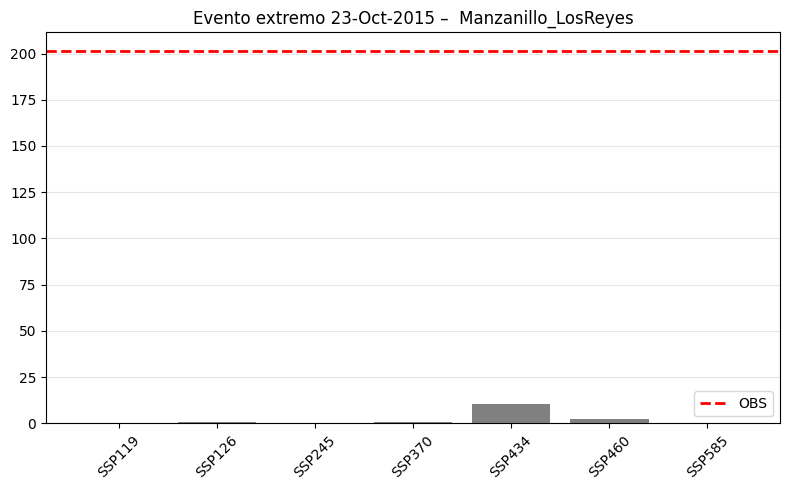

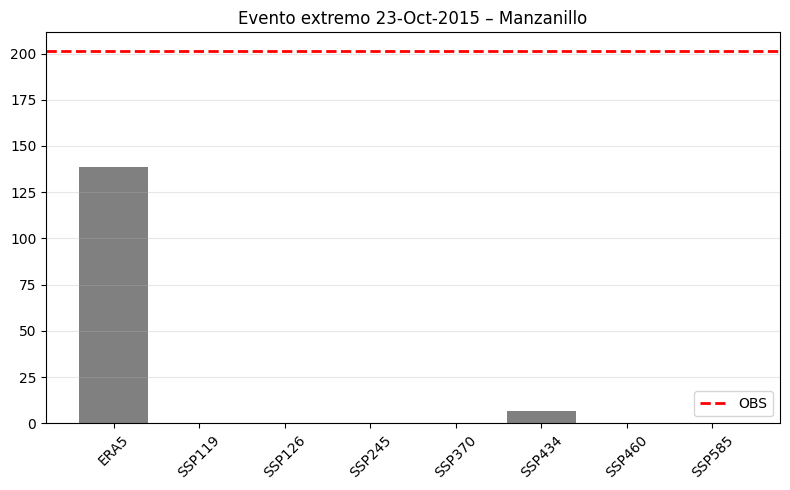

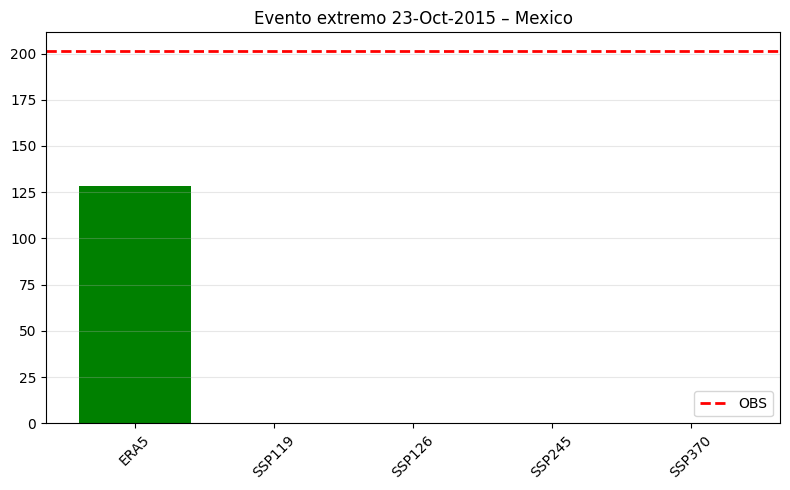

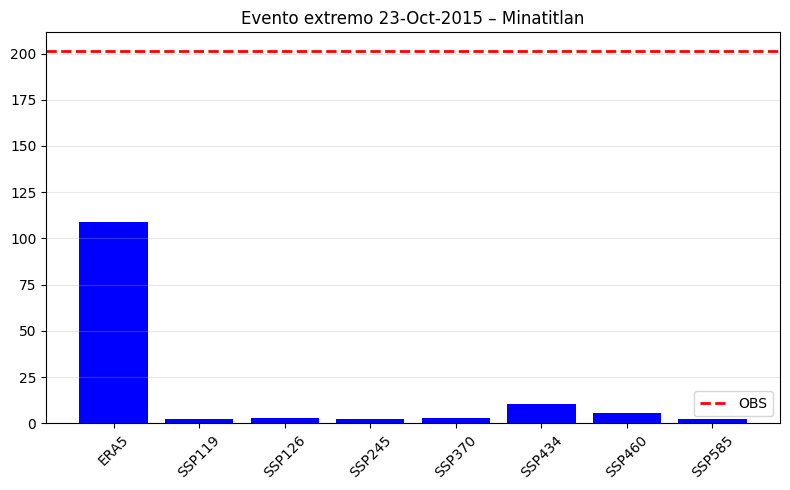

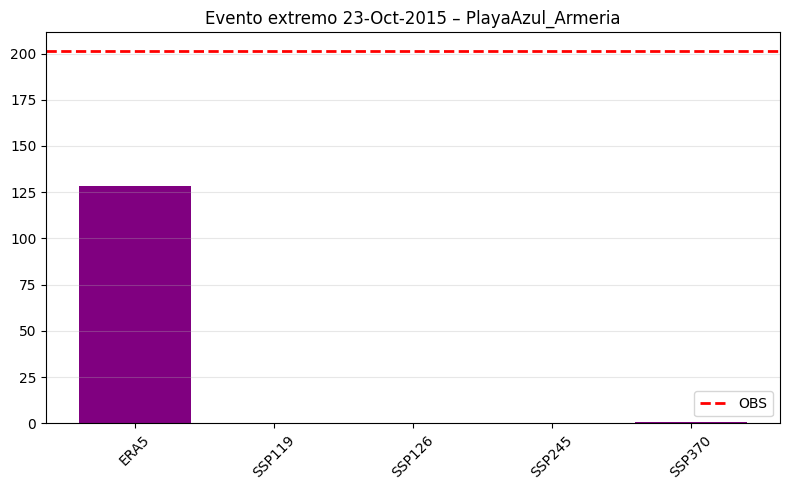

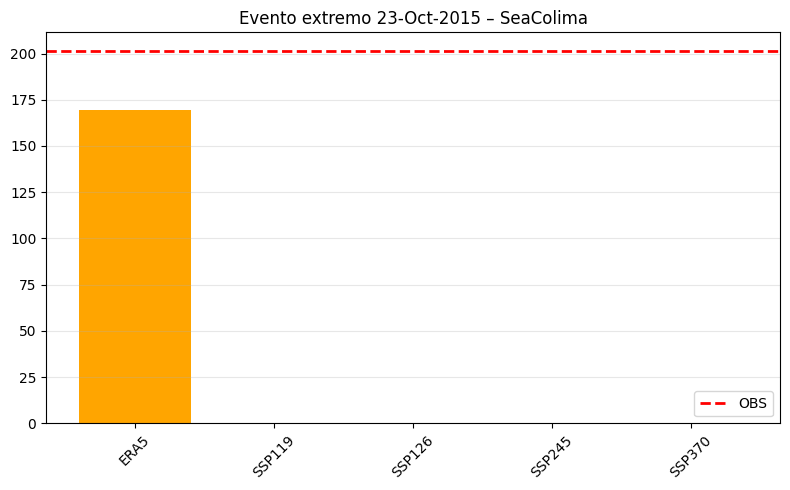

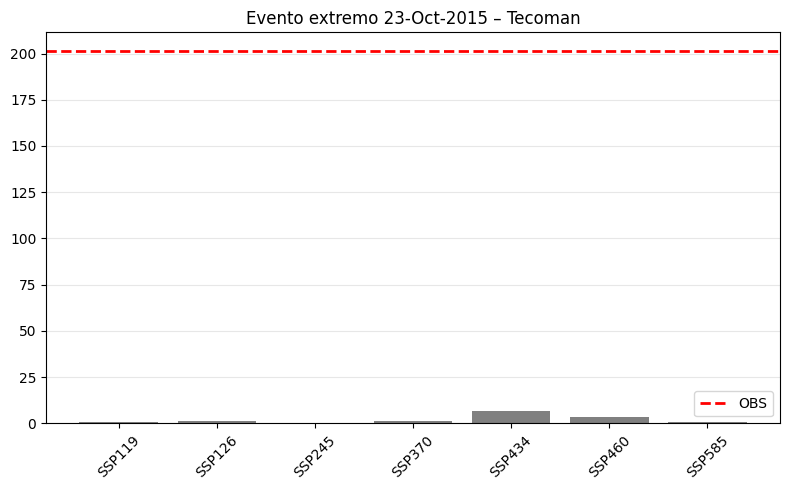

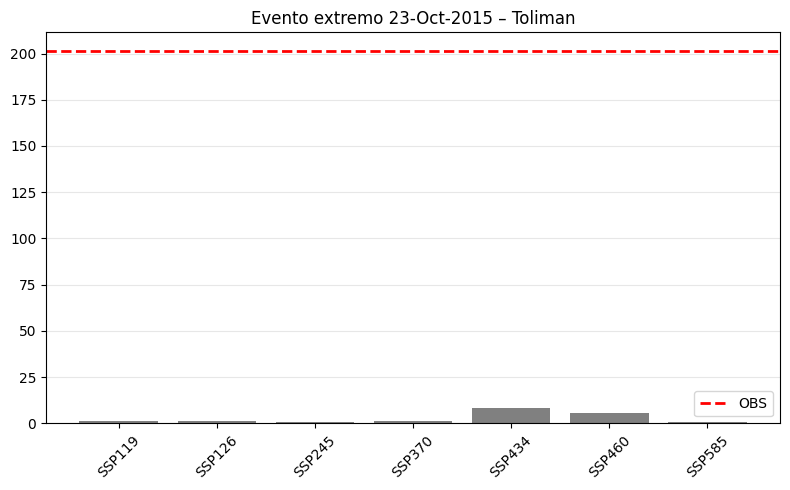

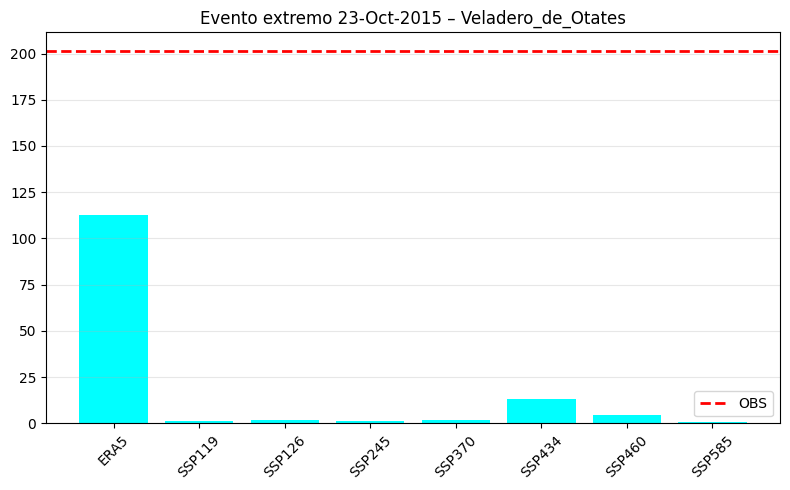

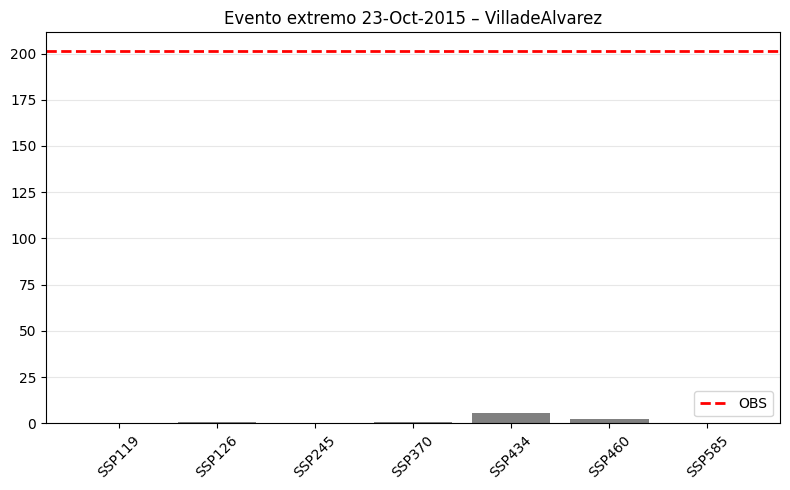

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import os

OUT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/EVENT_2015_ANALYSIS/Graficas"
os.makedirs(OUT_DIR, exist_ok=True)

# Limpiar nombres por seguridad
df_event_scenarios["sustax_total"] = df_event_scenarios["sustax_total"].astype(str).str.strip()
df_event_scenarios["scenario"] = df_event_scenarios["scenario"].astype(str).str.strip()

# Orden de escenarios (incluye ERA5 si lo usas)
scenario_order = ["ERA5", "SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

# Colores por punto (puedes ajustar nombres exactos según tu DF)
color_map = {
    "Sustax_MinatitlanTotal": "blue",
    "Sustax_Manzanillo_LosReyesTotal": "red",
    "Sustax_MexicoTotal": "green",
    "Sustax_PlayaAzul_ArmeriaTotal": "purple",
    "Sustax_SeaColimaTotal": "orange",
    "Sustax_Veladero_de_OtatesTotal": "cyan"
}

# Valor OBS
obs_value = 201.39

# 🔥 EXCLUSIÓN DE PUNTOS
exclude_points = [
    "Sustax_CuautitlanTotal",
    "Sustax_Zapotitlan_de_VadilloTotal"
]

points = sorted(df_event_scenarios["sustax_total"].unique())
points = [p for p in points if p not in exclude_points]

for point in points:

    df_plot = df_event_scenarios[df_event_scenarios["sustax_total"] == point].copy()

    df_plot = (
        df_plot.set_index("scenario")
        .reindex(scenario_order)
        .reset_index()
    )

    scenarios = df_plot["scenario"]
    values = df_plot["event_value_mm"]

    color = color_map.get(point, "gray")

    plt.figure(figsize=(8,5))

    plt.bar(scenarios, values, color=color)

    plt.axhline(obs_value, color="red", linestyle="--", linewidth=2, label="OBS")

    titulo = point.replace("Sustax_", "").replace("Total", "")
    plt.title(f"Evento extremo 23-Oct-2015 – {titulo}")

    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()

    # 🔥 GUARDAR
    filename = f"{point.replace(' ', '_')}.png"
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=300, bbox_inches="tight")

    plt.show()

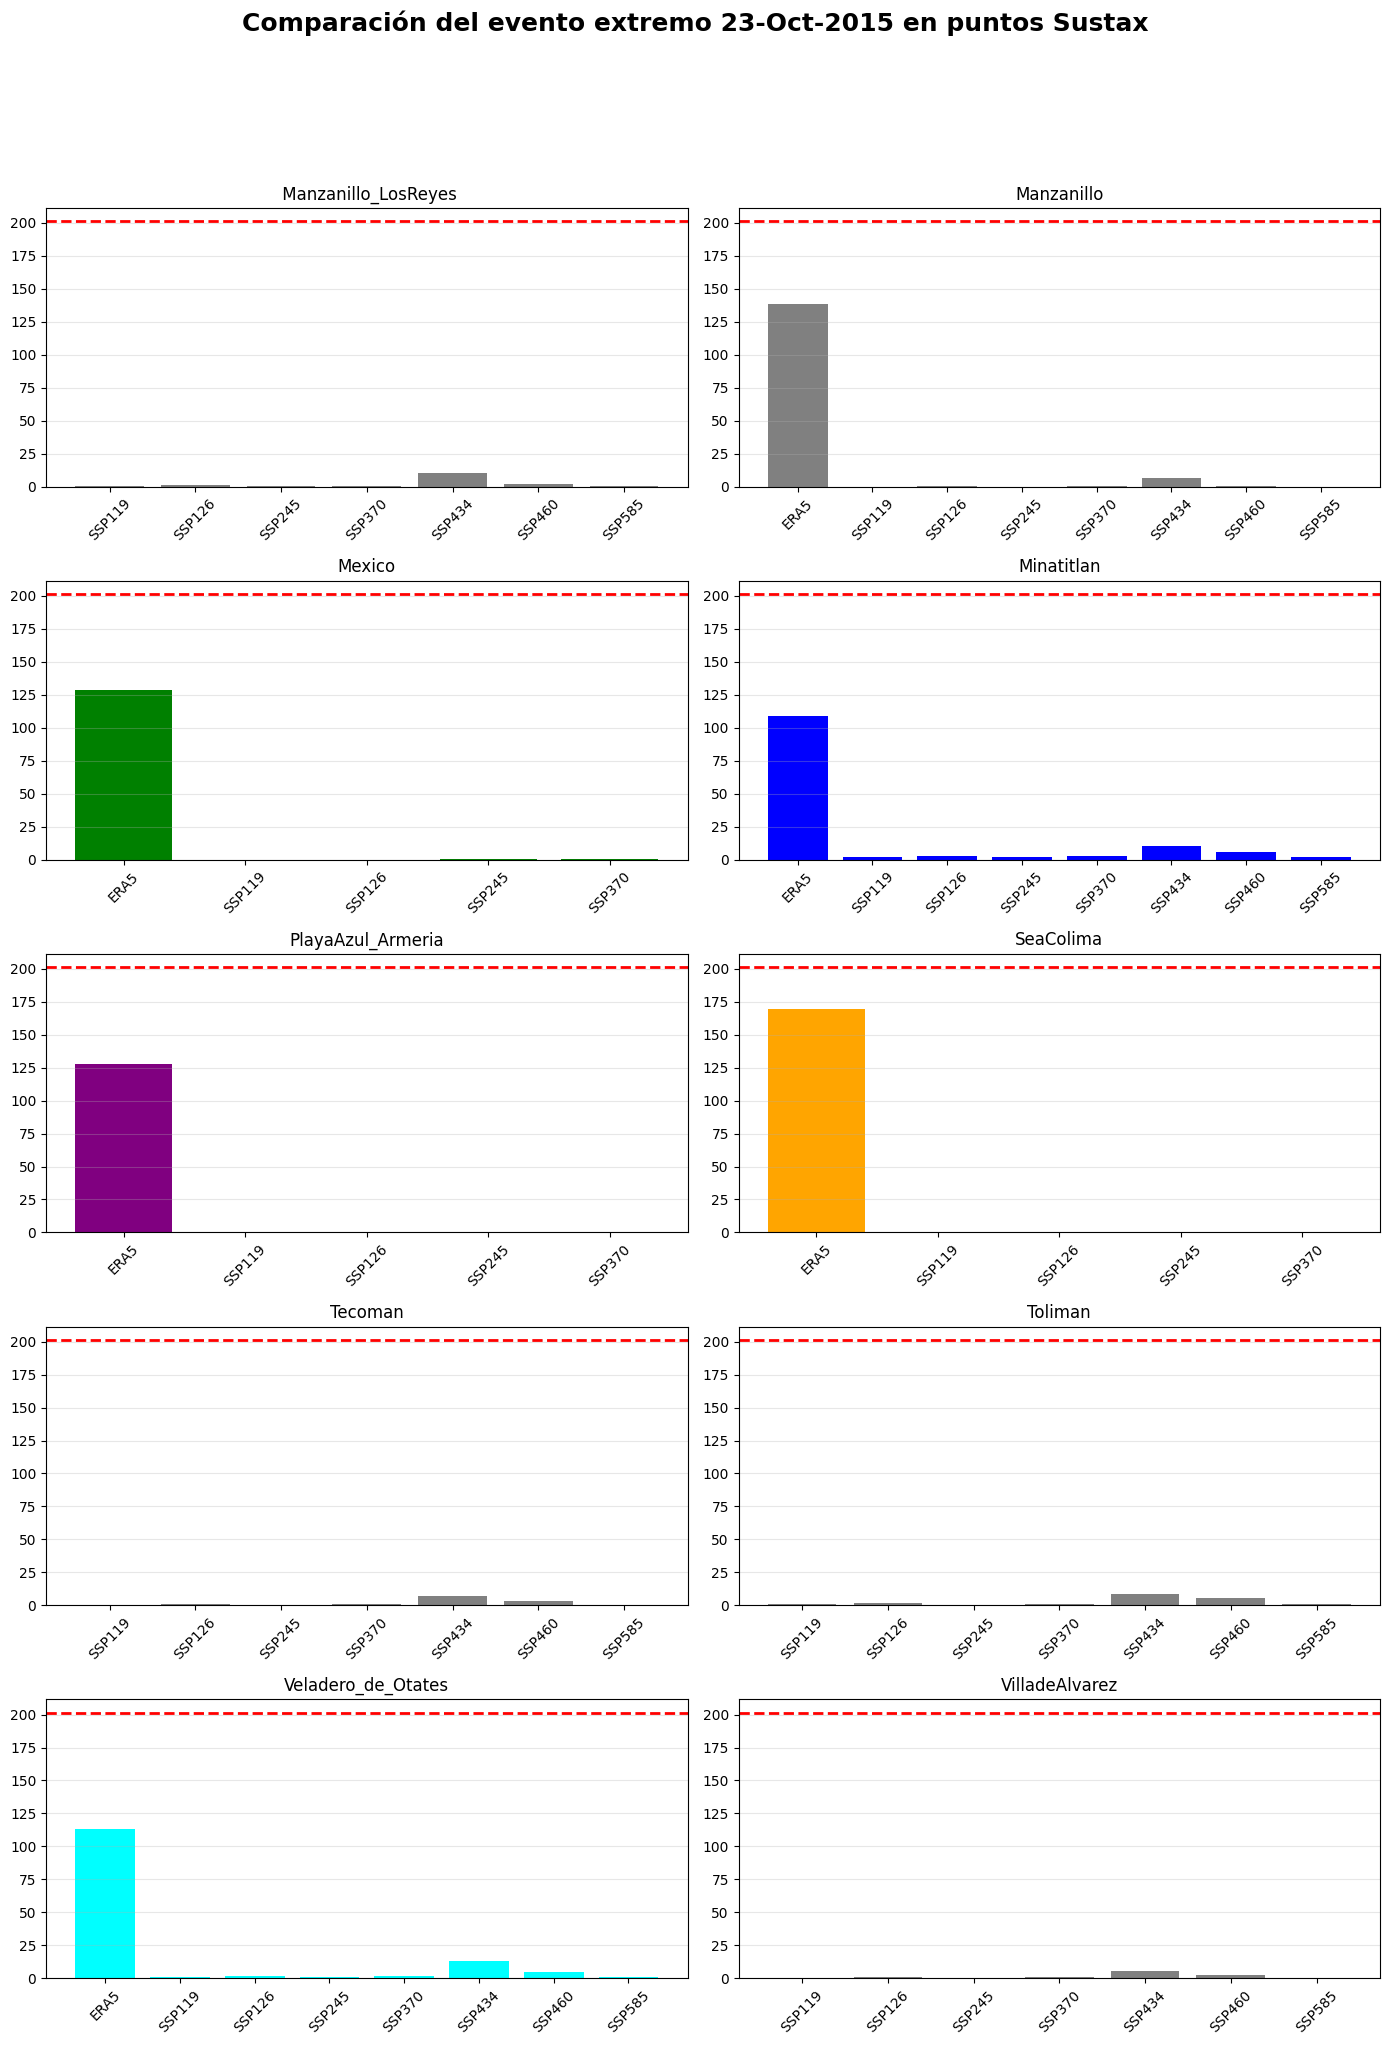

In [12]:
import math

n = len(points)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, rows*4))

axes = axes.flatten()

for i, point in enumerate(points):

    ax = axes[i]

    df_plot = df_event_scenarios[df_event_scenarios["sustax_total"] == point].copy()

    df_plot = (
        df_plot.set_index("scenario")
        .reindex(scenario_order)
        .reset_index()
    )

    scenarios = df_plot["scenario"]
    values = df_plot["event_value_mm"]

    color = color_map.get(point, "gray")

    ax.bar(scenarios, values, color=color)

    ax.axhline(obs_value, color="red", linestyle="--", linewidth=2)

    titulo = point.replace("Sustax_", "").replace("Total", "")
    ax.set_title(titulo)

    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

# quitar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Comparación del evento extremo 23-Oct-2015 en puntos Sustax",
    fontsize=18,
    fontweight="bold",
    y=1.02
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# GUARDAR FIGURA GLOBAL
plt.savefig(os.path.join(OUT_DIR, "Figura_global_evento_2015.png"), dpi=300, bbox_inches="tight")

plt.show()

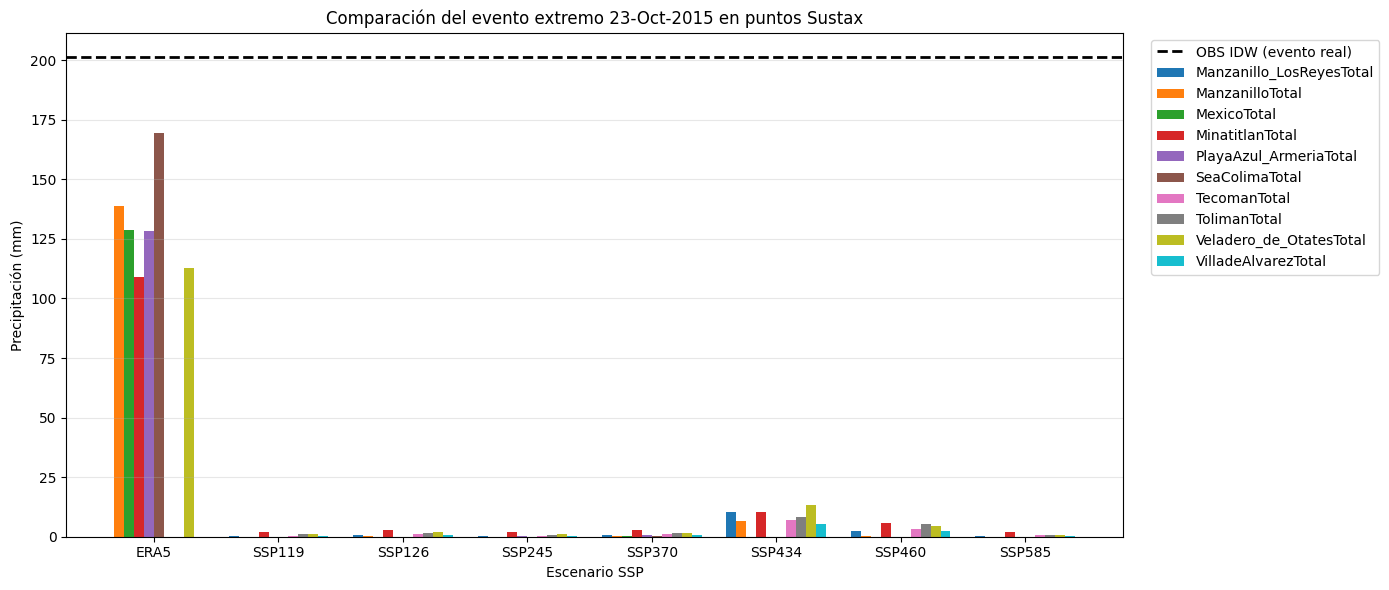

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Filtrar solo ERA5 y SSP
df_plot = df_event_scenarios[
    df_event_scenarios["scenario"].str.startswith(("ERA5","SSP"))
].copy()

# Normalizar nombres
df_plot["sustax_total"] = df_plot["sustax_total"].astype(str).str.strip()
df_plot["scenario"] = df_plot["scenario"].astype(str).str.strip()

# 🔥 EXCLUSIÓN DE PUNTOS
exclude_points = [
    "Sustax_CuautitlanTotal",
    "Sustax_Zapotitlan_de_VadilloTotal"
]

df_plot = df_plot[~df_plot["sustax_total"].isin(exclude_points)]

# Orden de escenarios
scenario_order = ["ERA5","SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

# Obtener puntos filtrados
points = sorted(df_plot["sustax_total"].unique())

# Colores automáticos
cmap = plt.get_cmap("tab10")
color_map = {point: cmap(i % 10) for i, point in enumerate(points)}

# Posiciones
x = np.arange(len(scenario_order))
width = 0.8 / max(len(points), 1)

plt.figure(figsize=(14, 6))

for i, point in enumerate(points):

    sub = df_plot[df_plot["sustax_total"] == point][["scenario", "event_value_mm"]].copy()

    sub = (
        sub.set_index("scenario")
        .reindex(scenario_order)
        .reset_index()
    )

    values = sub["event_value_mm"].to_numpy(dtype=float)

    plt.bar(
        x + i * width,
        values,
        width=width,
        label=point.replace("Sustax_", "").strip(),
        color=color_map[point]
    )

# Línea OBS
obs_value = 201.392467
plt.axhline(
    obs_value,
    color="black",
    linestyle="--",
    linewidth=2,
    label="OBS IDW (evento real)"
)

plt.xticks(x + width * (len(points) - 1) / 2, scenario_order)
plt.ylabel("Precipitación (mm)")
plt.xlabel("Escenario SSP")
plt.title("Comparación del evento extremo 23-Oct-2015 en puntos Sustax")
plt.grid(axis="y", alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
# GUARDAR FIGURA GLOBAL
plt.savefig(os.path.join(OUT_DIR, "Comparación de todos los puntos Sustax con Patricia"), dpi=300, bbox_inches="tight")
plt.show()


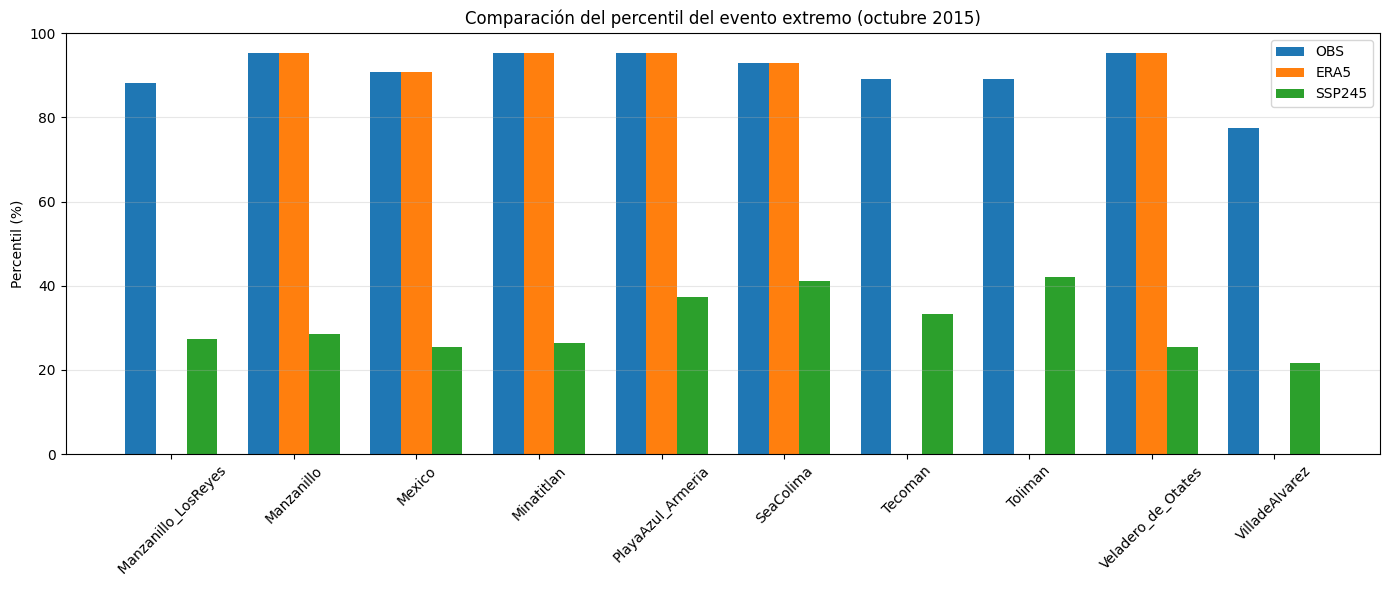

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

OUT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/EVENT_2015_ANALYSIS/Graficas"
os.makedirs(OUT_DIR, exist_ok=True)

# copiar y limpiar
df = df_event_scenarios.copy()
df["sustax_total"] = df["sustax_total"].astype(str).str.strip()
df["scenario"] = df["scenario"].astype(str).str.strip()

# excluir puntos
exclude_points = [
    "Sustax_CuautitlanTotal",
    "Sustax_Zapotitlan_de_VadilloTotal"
]
df = df[~df["sustax_total"].isin(exclude_points)]

# escenarios a comparar
scenarios_use = ["ERA5", "SSP245"]

# modelo
df_model = df[df["scenario"].isin(scenarios_use)].copy()

# OBS como proxy: máximo percentil por punto
df_obs = (
    df.groupby("sustax_total", as_index=False)["october_percentile"]
    .max()
)
df_obs["scenario"] = "OBS"
df_obs = df_obs.rename(columns={"october_percentile": "plot_percentile"})

# ERA5 y SSP245
df_model = df_model.rename(columns={"october_percentile": "plot_percentile"})
df_model = df_model[["sustax_total", "scenario", "plot_percentile"]]

# combinar
df_plot = pd.concat(
    [
        df_obs[["sustax_total", "scenario", "plot_percentile"]],
        df_model
    ],
    ignore_index=True
)

# orden
scenario_order = ["OBS", "ERA5", "SSP245"]
points = sorted(df_plot["sustax_total"].unique())

x = np.arange(len(points))
width = 0.25

plt.figure(figsize=(14, 6))

for i, sc in enumerate(scenario_order):
    sub = df_plot[df_plot["scenario"] == sc].copy()

    # reindexar por puntos para evitar desajustes
    sub = (
        sub.set_index("sustax_total")
        .reindex(points)
        .reset_index()
    )

    values = sub["plot_percentile"].to_numpy(dtype=float)

    plt.bar(
        x + i * width,
        values,
        width=width,
        label=sc
    )

plt.xticks(
    x + width,
    [p.replace("Sustax_", "").replace("Total", "") for p in points],
    rotation=45
)

plt.ylabel("Percentil (%)")
plt.title("Comparación del percentil del evento extremo (octubre 2015)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "percentiles_evento_2015.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

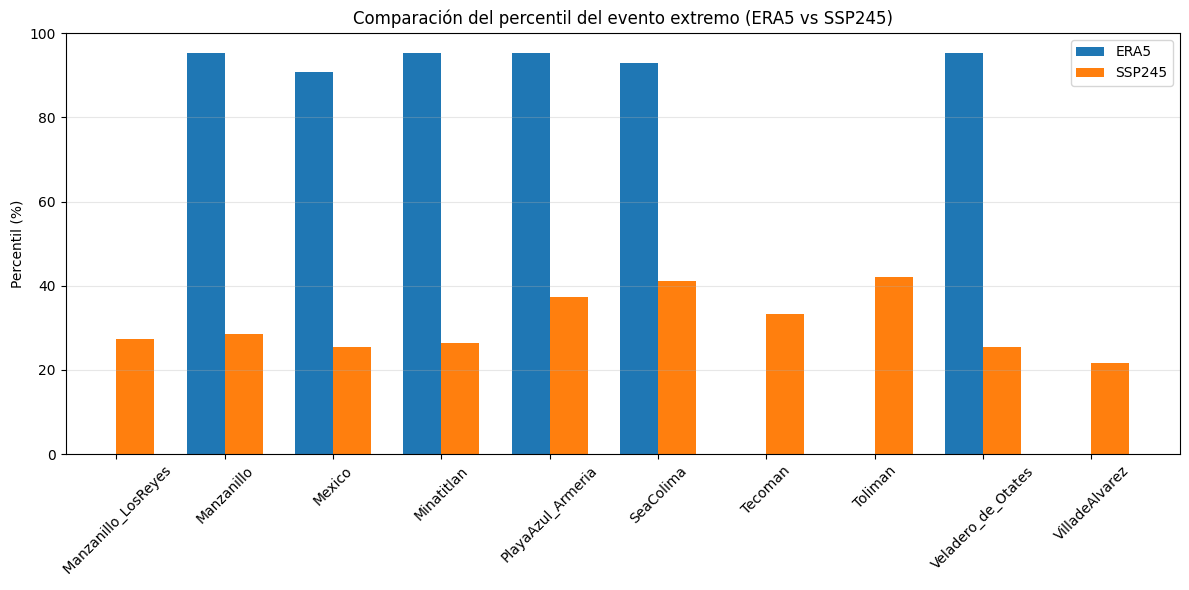

In [16]:
df_plot = df_event_scenarios.copy()

df_plot["sustax_total"] = df_plot["sustax_total"].str.strip()
df_plot["scenario"] = df_plot["scenario"].str.strip()

exclude_points = [
    "Sustax_CuautitlanTotal",
    "Sustax_Zapotitlan_de_VadilloTotal"
]

df_plot = df_plot[~df_plot["sustax_total"].isin(exclude_points)]

df_plot = df_plot[df_plot["scenario"].isin(["ERA5", "SSP245"])]

points = sorted(df_plot["sustax_total"].unique())

x = np.arange(len(points))
width = 0.35

plt.figure(figsize=(12,6))

for i, sc in enumerate(["ERA5", "SSP245"]):

    sub = df_plot[df_plot["scenario"] == sc].copy()

    sub = (
        sub.set_index("sustax_total")
        .reindex(points)
        .reset_index()
    )

    plt.bar(
        x + i*width,
        sub["october_percentile"],
        width=width,
        label=sc
    )

plt.xticks(
    x + width/2,
    [p.replace("Sustax_","").replace("Total","") for p in points],
    rotation=45
)

plt.ylabel("Percentil (%)")
plt.title("Comparación del percentil del evento extremo (ERA5 vs SSP245)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()